In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
import os

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
print(esc_fresnel.path)

import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel as esc
import esc_fresnel.esc_optics as esc_optics


/home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
2025-03-15 15:44:18,841	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


/home/kianmilani/Projects/esc-fresnel/esc_fresnel


# Create an instance of the Fresnel model and check some of the parameters used in the propagation code. 

1


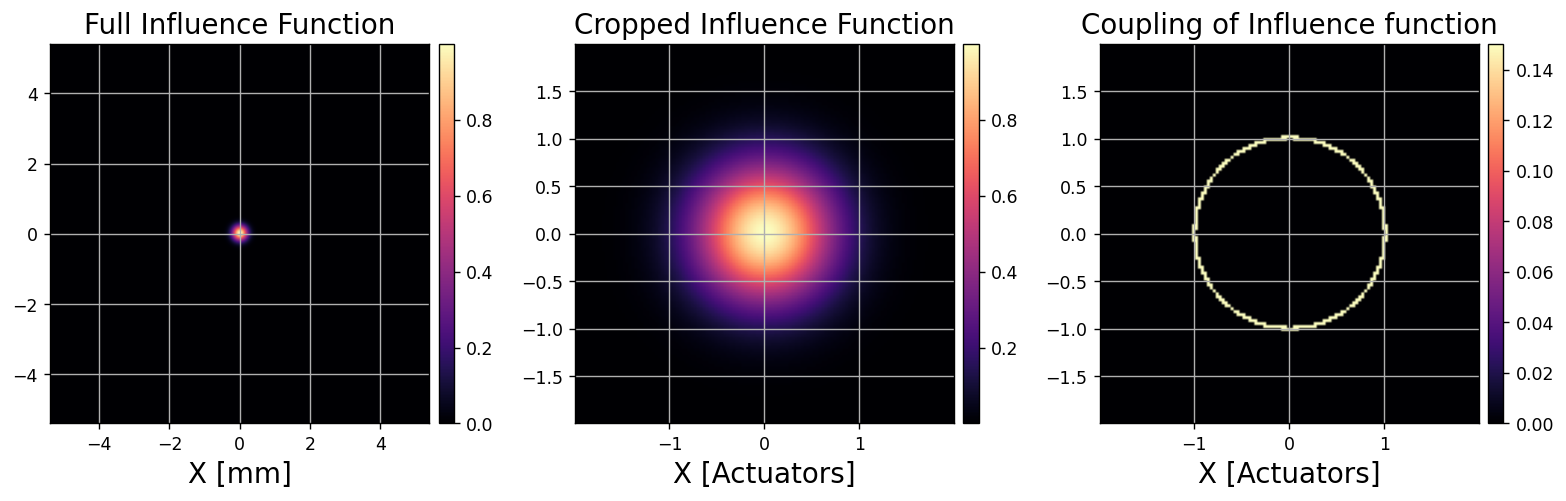

In [2]:
reload(esc)
M = esc.single()

inf_fun_coupling_region = (0.15-0.01<M.DM.inf_fun) & (M.DM.inf_fun<0.15+0.01)

imshow(
    [M.DM.inf_fun, M.DM.inf_fun, inf_fun_coupling_region],
    titles=['Full Influence Function', 'Cropped Influence Function', 'Coupling of Influence function'],
    xlabels=['X [mm]', 'X [Actuators]', 'X [Actuators]'],
    title_fzs=[16]*3,
    label_fzs=[16]*3,
    pxscls=[M.DM.pixelscale.to_value(u.mm/u.pix), 1/M.DM.inf_sampling, 1/M.DM.inf_sampling],
    cmaps=['magma']*3,
    grids=[1]*3,
    norms=[None, None, Normalize(vmax=0.15)],
    npix=[None, int(np.round(4*M.DM.inf_sampling)), int(np.round(4*M.DM.inf_sampling))],
    wspace=0.3,
)

# Compute the focal plane image with and without the vortex.

1


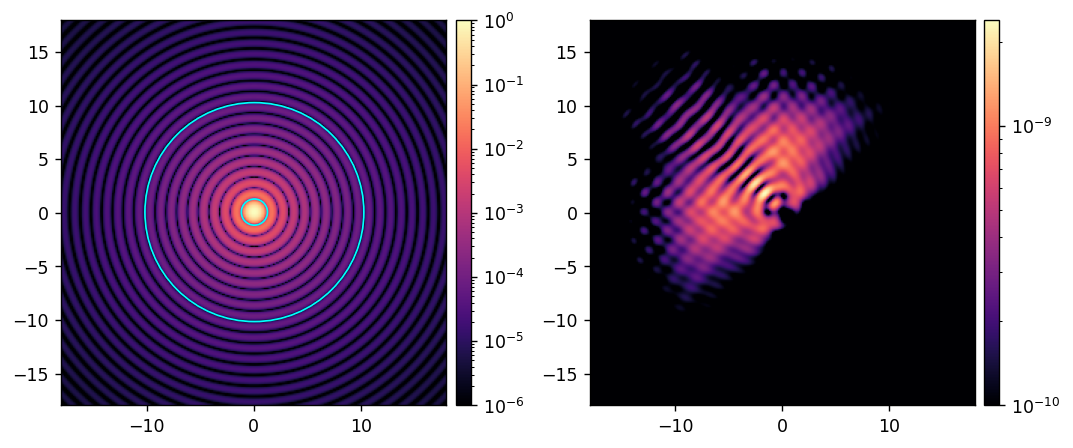

In [3]:
reload(esc)

# poppy_log.disabled = False
poppy_log.disabled = True

M = esc.single(
    npix=1000, 
    oversample=4.096, 
    npsf=256,
)
ref_psf = M.snap()

M.Imax_ref = xp.max(ref_psf)
M.use_vortex = True
ref_coro_im = M.snap()

psf_center = (M.camsci_pxscl_lamDc/2, M.camsci_pxscl_lamDc/2)
imshow(
    [ref_psf/M.Imax_ref, ref_coro_im], 
    cmaps=['magma']*2,
    norms=[LogNorm(1e-6), LogNorm(1e-10)],
    pxscls=[M.camsci_pxscl_lamDc]*2,
    all_patches=[ [Circle(psf_center, 1.22, fill=False, color='cyan'), Circle(psf_center, 10.22, fill=False, color='cyan')] ],
)

# Use ESC fresnel model to compute the wavefront at each plane and visualize the various pupil and focal planes.

Note that this is very memory intesive and is only meant to be used for understanding and debugging the Fresnel model. Standard propagations should only use calc_wf() or snap() methods, not calc_wfs(). 

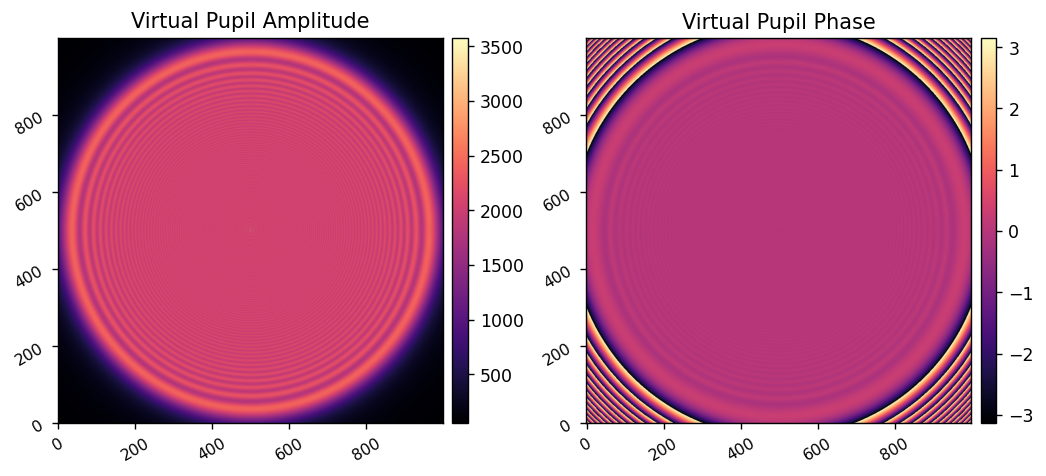

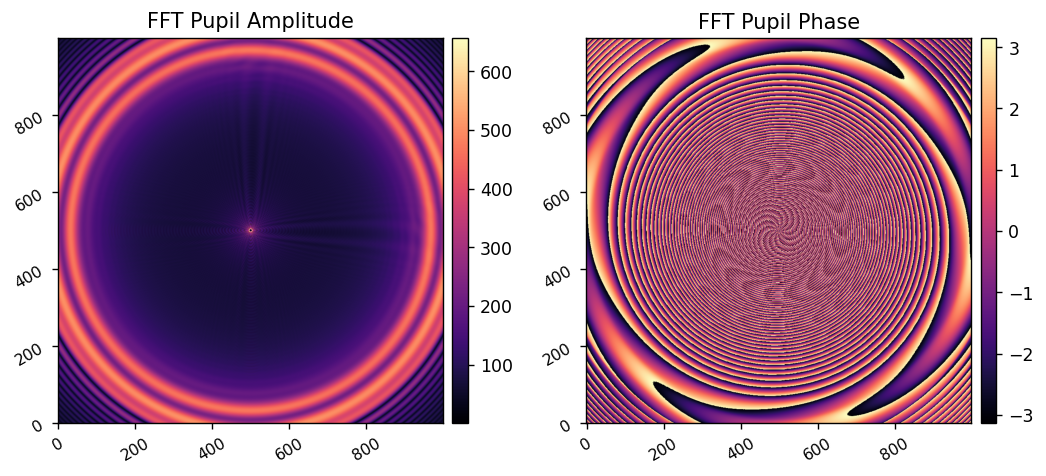

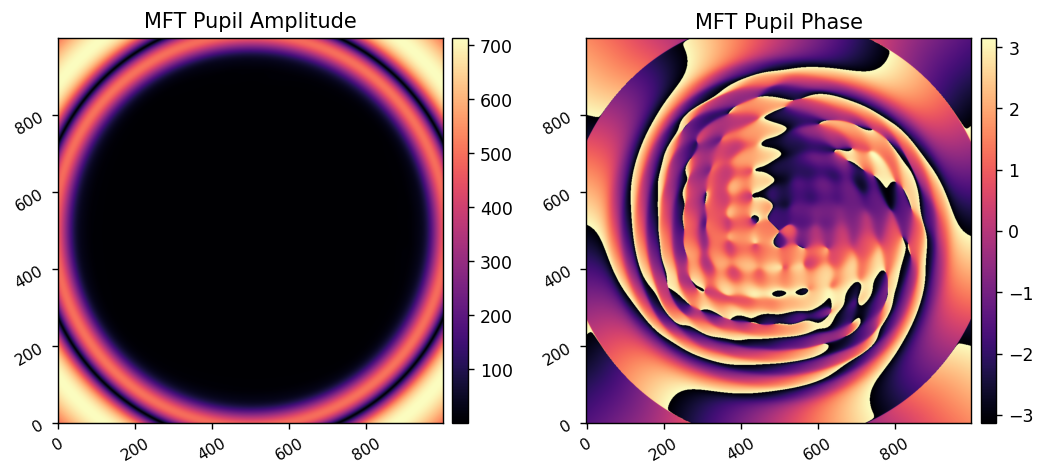

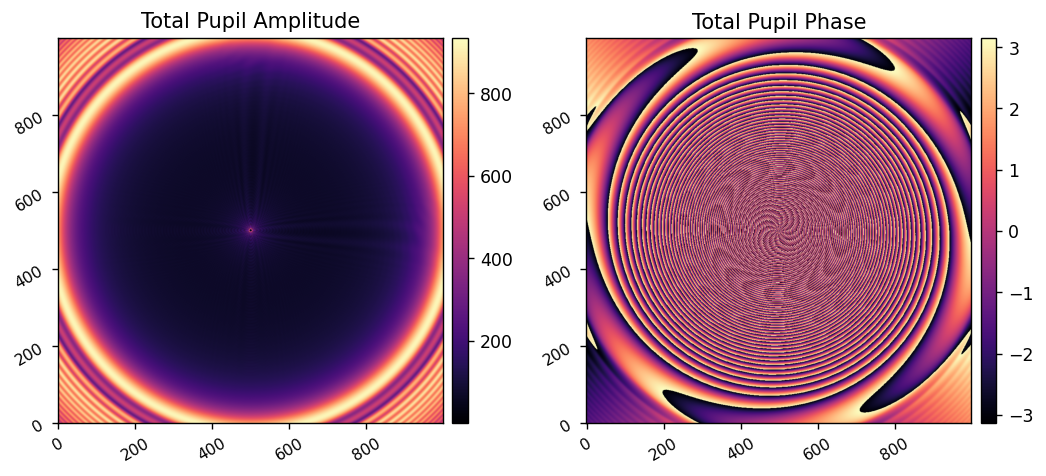

1


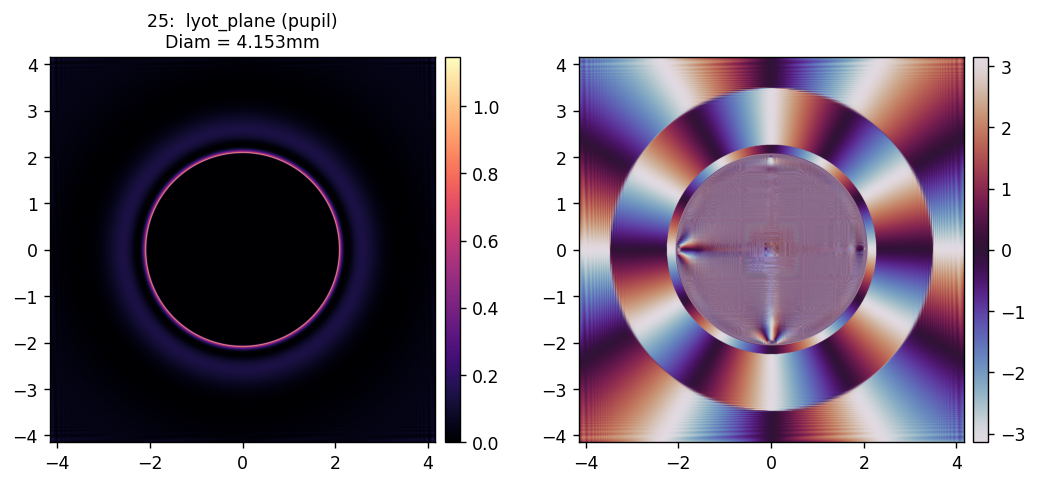

In [10]:
reload(esc)

poppy_log.disabled = True

M = esc.single(
    npix=1000, 
    oversample=2.048,
)
M.use_vortex = True
M.plot_vortex = True # this will display the intermediate steps while propagating through the vortex

wfs = M.calc_wfs()

i = 24 # OAP7
i = 25 # Lyot
wf = wfs[i]
imshow(
    [wf.intensity, wf.phase], 
    titles=[f'{i:d}: '+wf.location[5:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm'], 
    pxscls=[wf.pixelscale.to_value(u.mm/u.pix)]*2,
    npix=[2*M.npix]*2, 
    cmaps=['magma', 'twilight'],
)

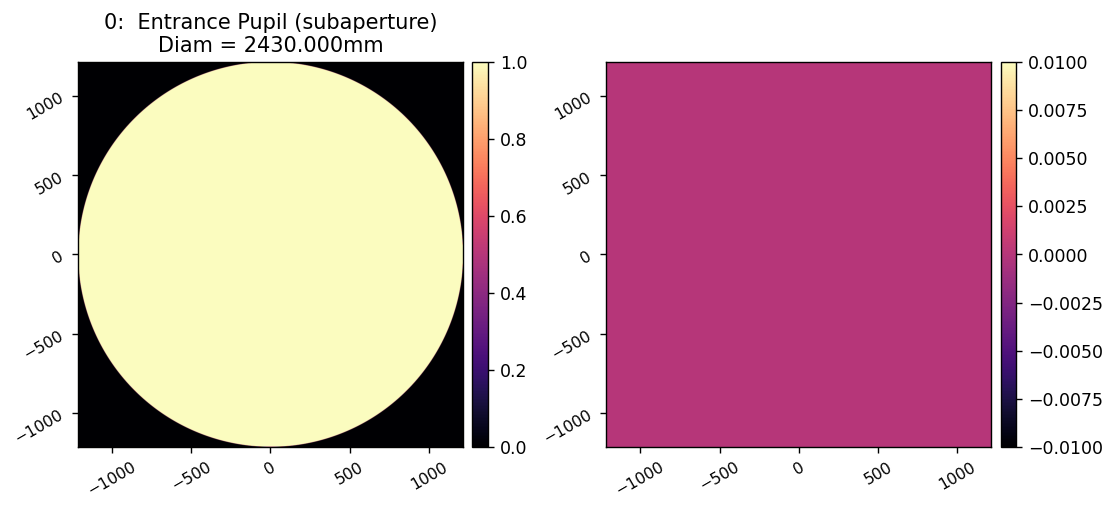

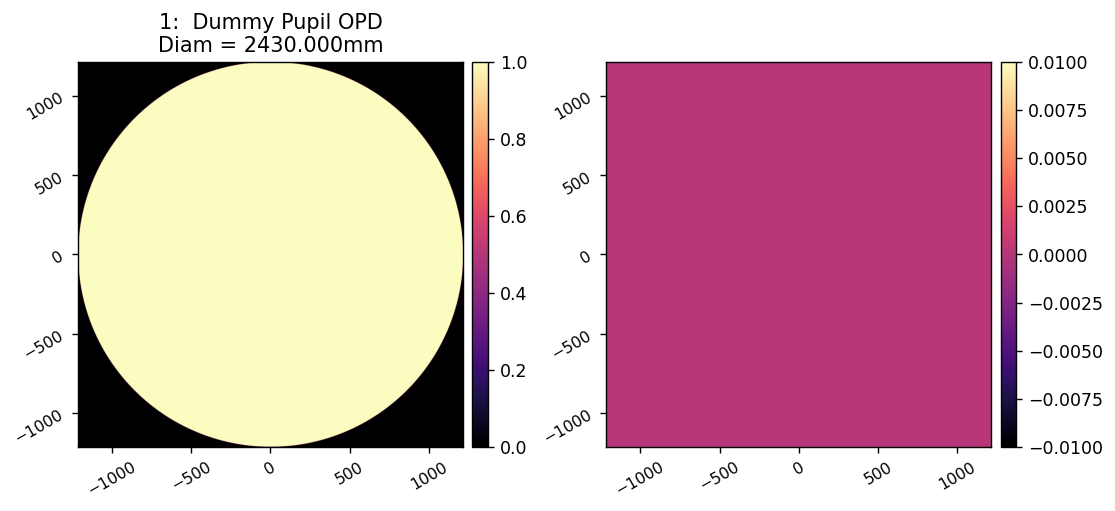

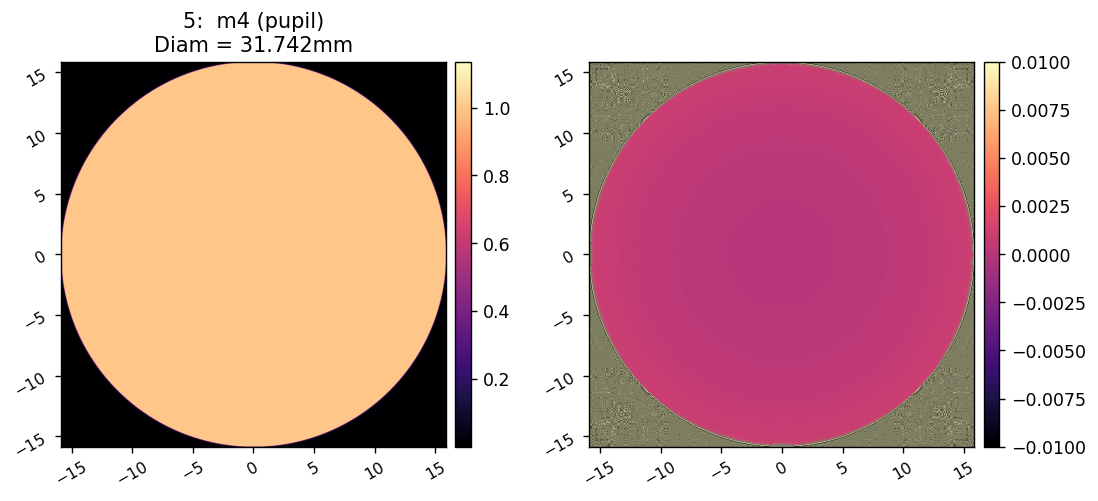

Focal Plane Correction:  0.0 mm


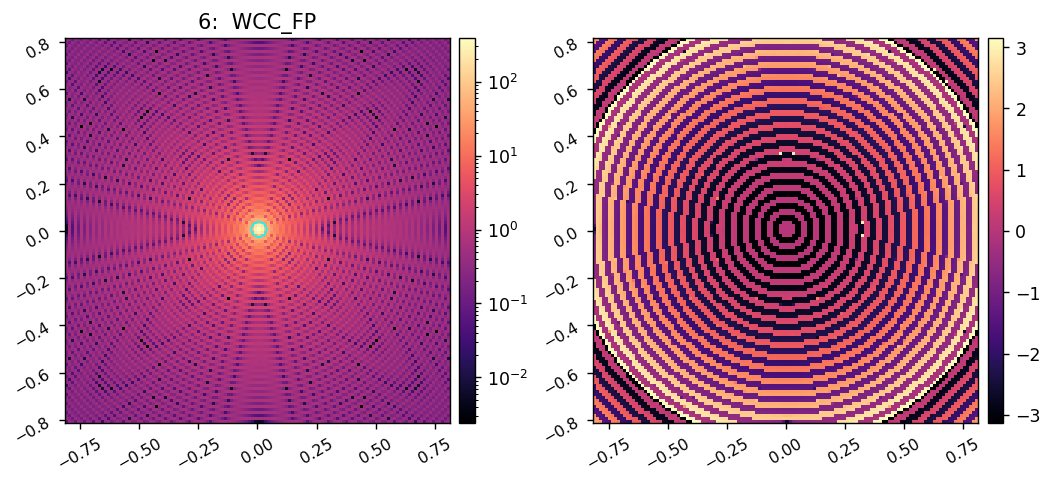

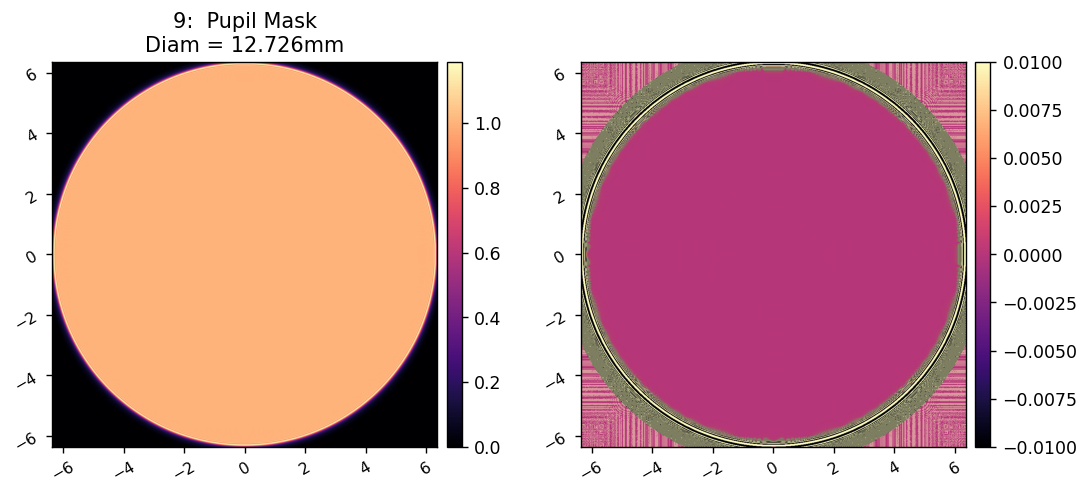

Focal Plane Correction:  0.0 mm


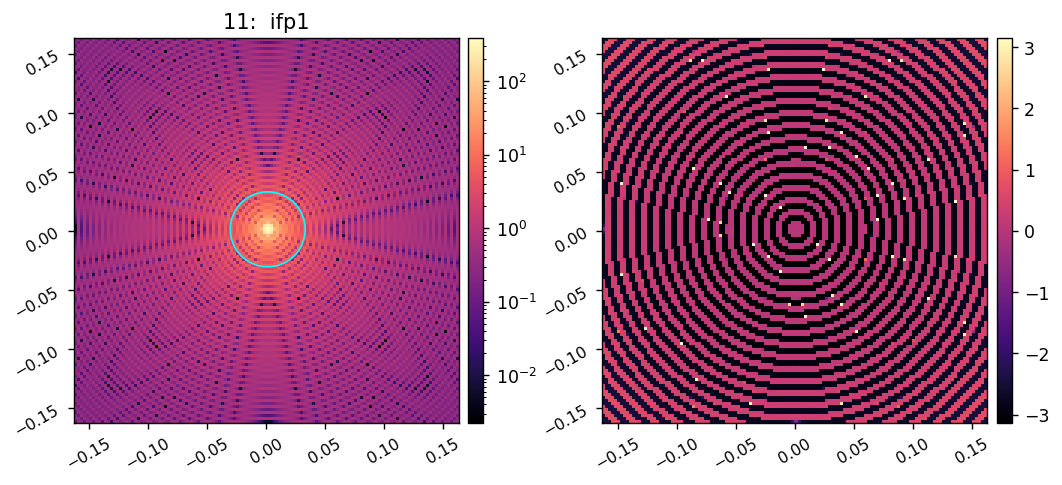

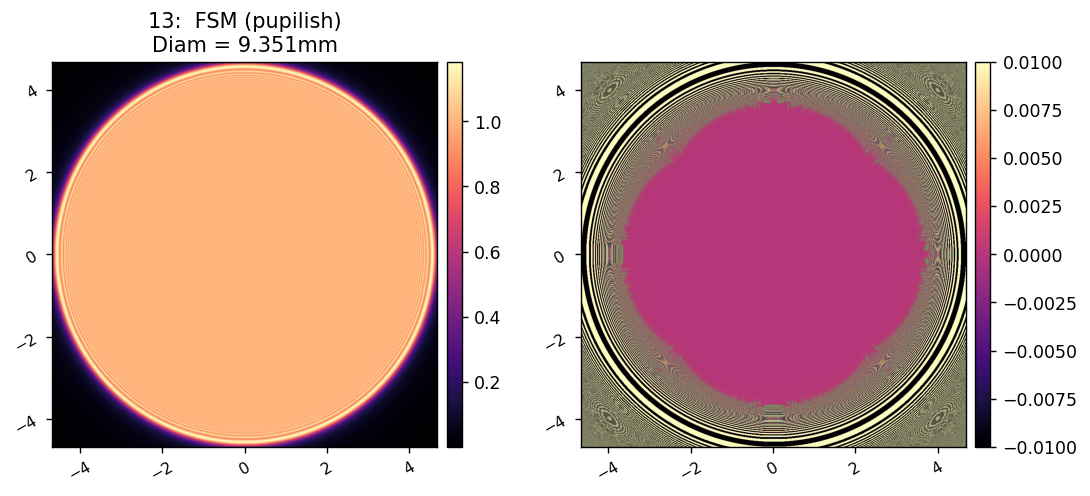

Focal Plane Correction:  0.0 mm


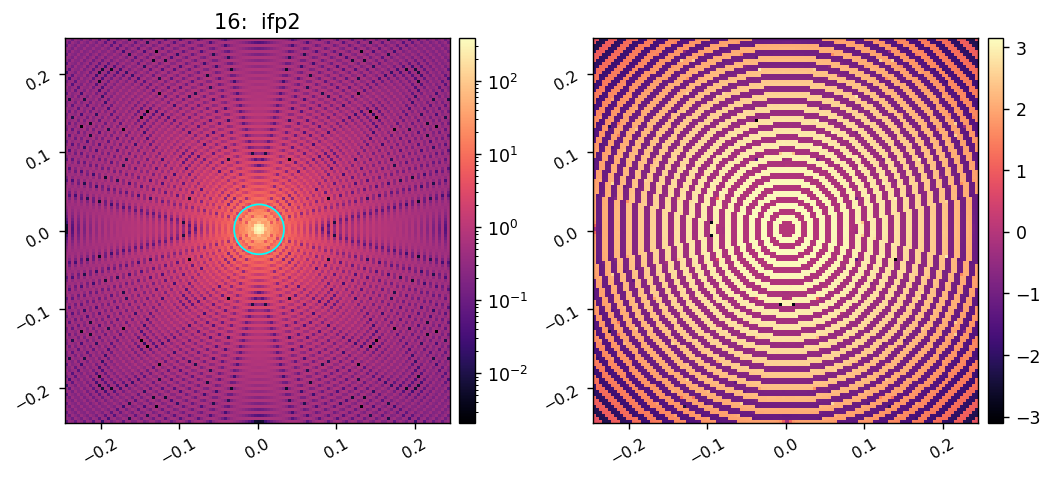

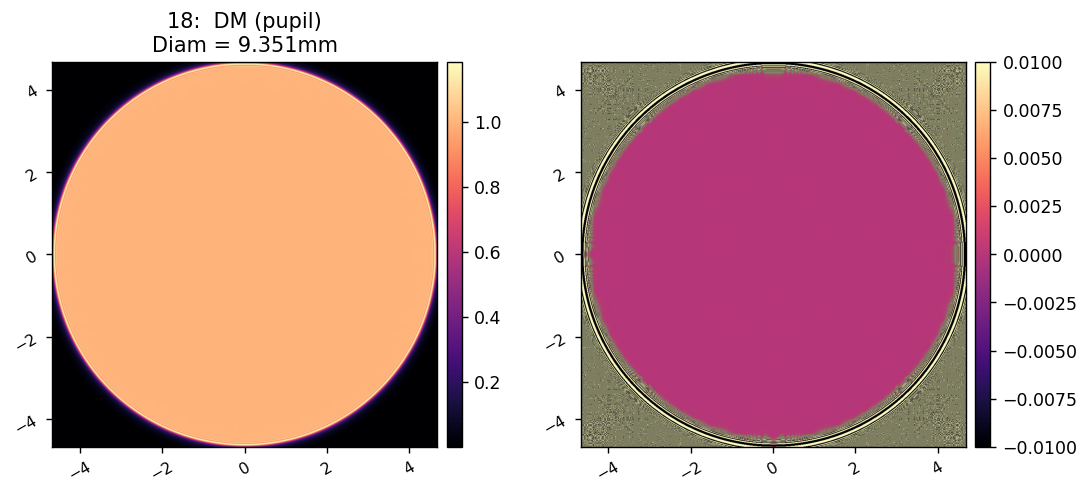

Focal Plane Correction:  -1541.0562467009754 mm


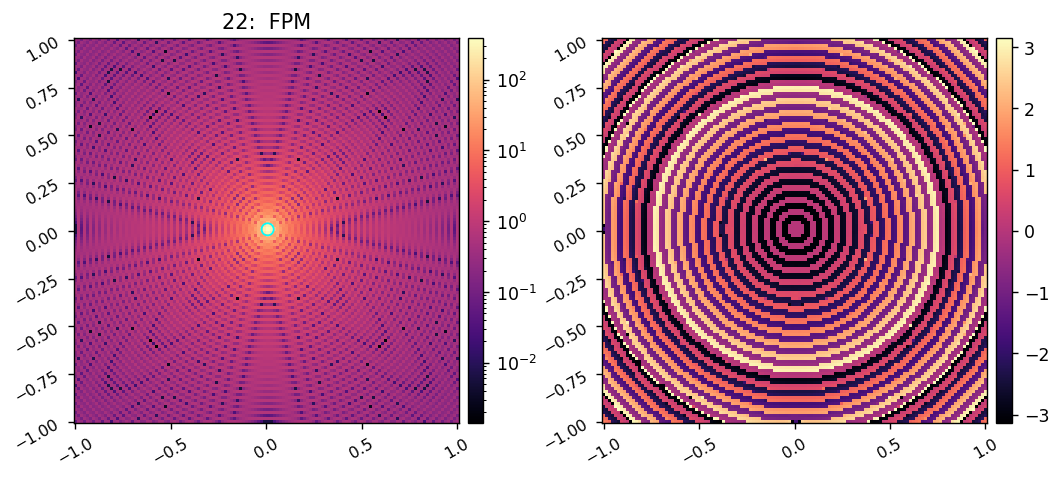

Focal Plane Correction:  0.0 mm


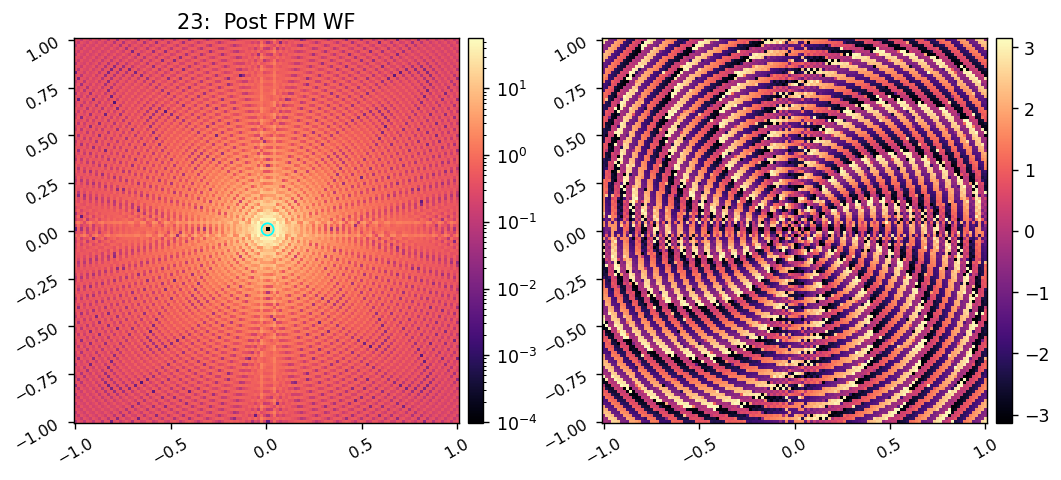

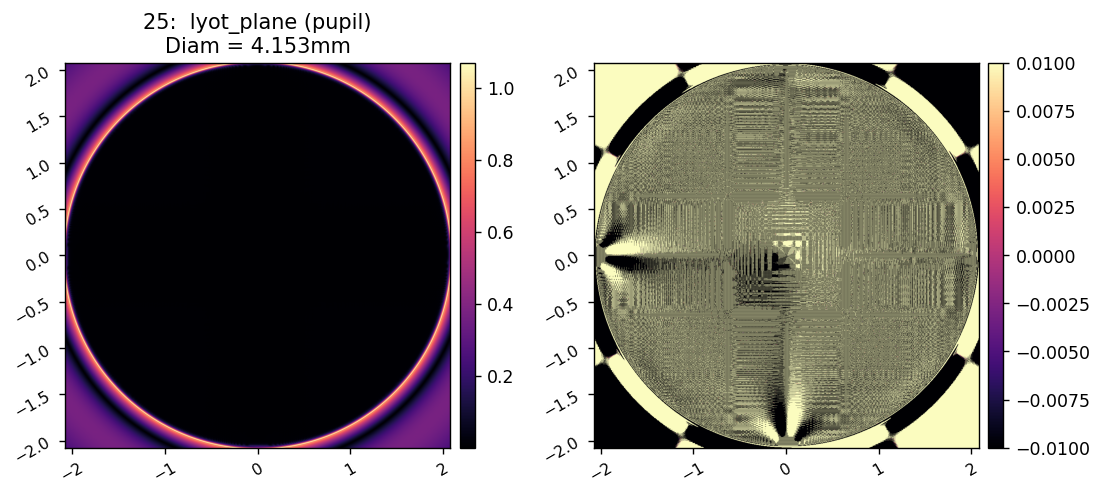

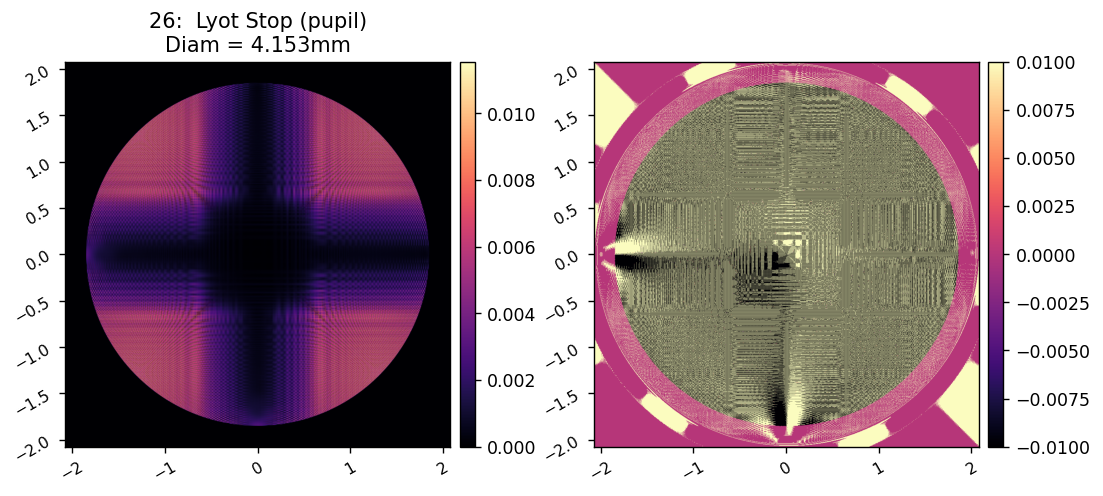

Focal Plane Correction:  0.0 mm


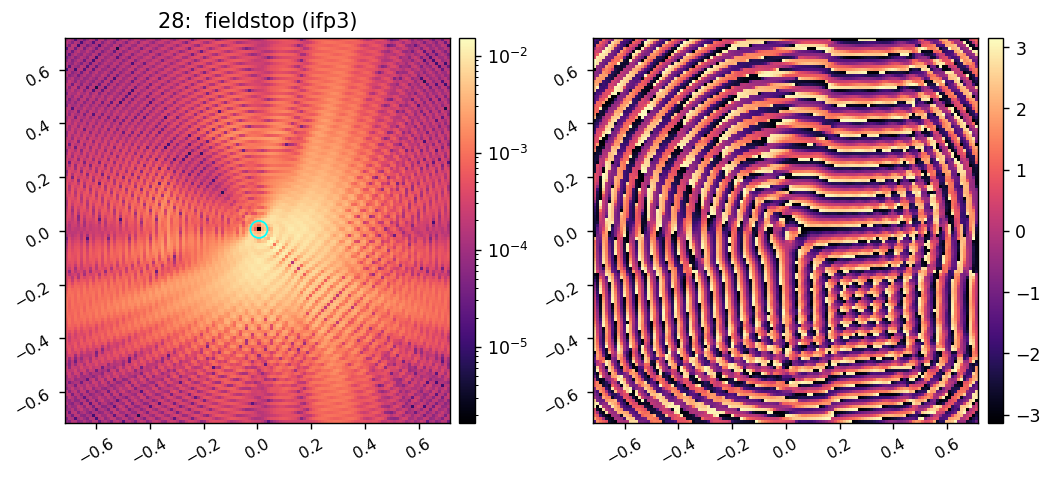

Focal Plane Correction:  0.0 mm


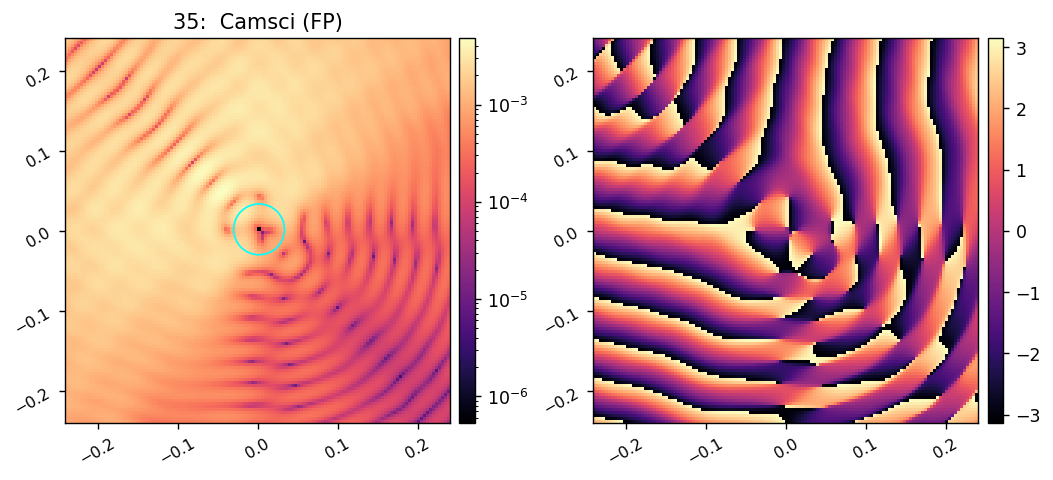

In [11]:
for i,wf in enumerate(wfs):
    if 'fp' in wf.location.lower():
        f_corr = wf.z_w0 - wf.z
        print('Focal Plane Correction: ', f_corr.to(u.mm))
        pxscl_mm = wf.pixelscale.to_value(u.mm/u.pix)
        airy_rad = 31.752*u.um
        imshow2(
            wf.amplitude, wf.phase, 
            f'{i:d}: '+wf.location[5:], 
            pxscl=pxscl_mm, 
            npix=128, 
            lognorm1=True,
            patches1=[Circle((pxscl_mm/2, pxscl_mm/2), airy_rad.to_value(u.mm), color='cyan', fill=False)]
        )
    elif 'pupil' in wf.location.lower():
        imshow2(
            wf.amplitude, wf.phase, 
            f'{i:d}: '+wf.location[5:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm', 
            pxscl=wf.pixelscale.to(u.mm/u.pix), 
            npix=M.npix, 
            vmin2=-0.01, vmax2=0.01,
        )

# Use the esc_fresnel.multi() class in order to do parallelized propagations to simulate a broadband image. This requires the Ray package to perform the parallelization. 

In [4]:
reload(esc)

import ray
ray_esc = ray.remote(esc.single)

N_waves = 5
bw = 0.1
wavelength_c = 650*u.nm
waves = np.linspace(wavelength_c*(1 - bw/2), wavelength_c*(1 + bw/2), N_waves)
print(waves)

[617.5  633.75 650.   666.25 682.5 ] nm


In [5]:
ACTORS = []
for i in range(N_waves):
    params = {
        'wavelength':waves[i],
    }
    ACTORS.append(ray_esc.options(num_cpus=1, num_gpus=1/2).remote(**params))


2025-03-15 15:45:02,198	INFO worker.py:1832 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


(pid=276961) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
(pid=276961)   cupy._util.experimental('cupyx.jit.rawkernel')
(single pid=276961) Oversampling > 2x suggested for reliable results in Fresnel propagation.
(pid=276954) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future. [repeated 4x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=276954)   cupy._util.experimental('cupyx.jit.rawkernel') [repeated 4x across cluster]


1


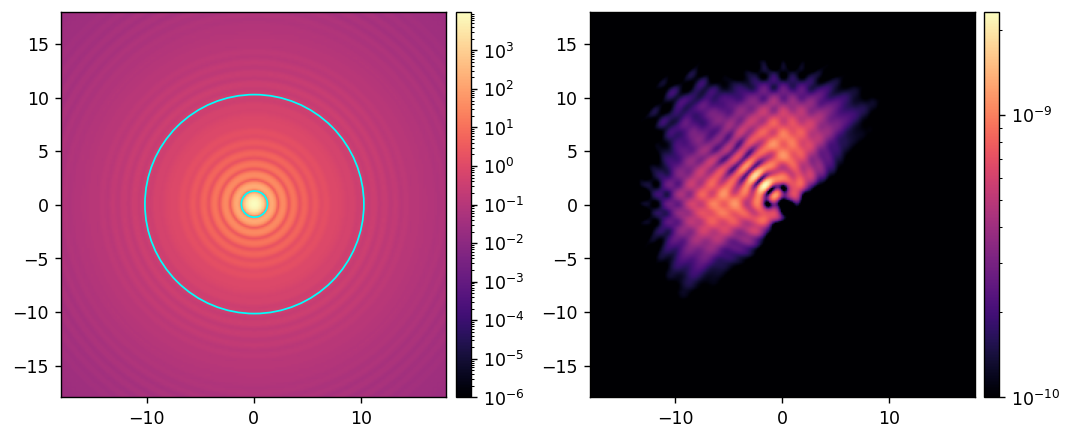

In [16]:
reload(esc)
M = esc.parallel(ACTORS)
# M.set_actor_attr('wfes', wfes)

M.setattr('Imax_ref', 1)
M.setattr('use_vortex', False)
ref_psf = M.snap()
# M.Imax_ref = xp.max(ref_psf)
M.setattr('Imax_ref', xp.max(ref_psf))

M.setattr('use_vortex', True)
ref_coro_im = M.snap()

psf_center = (M.camsci_pxscl_lamDc/2, M.camsci_pxscl_lamDc/2)
imshow(
    [ref_psf/M.Imax_ref, ref_coro_im], 
    cmaps=['magma']*2,
    norms=[LogNorm(1e-6), LogNorm(1e-10)],
    pxscls=[M.camsci_pxscl_lamDc]*2,
    all_patches=[ [Circle(psf_center, 1.22, fill=False, color='cyan'), Circle(psf_center, 10.22, fill=False, color='cyan')] ],
)